# MCal Loss Functions Test

This notebook tests different loss functions (KL_Exp, Exp_KL, CE) from MCal_Test class on the MRI dataset with kappa=1.0

In [12]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import sys
import timm

# Add project paths
project_root = Path().absolute().parent
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(project_root / "src"))
sys.path.insert(0, str(project_root / "configs"))

from src.calibrators.mcal_test import MCal_Test
from src.data.loaders.vision_loaders import MRILoader
from configs.model_dict import get_model_path
from configs.dataset_configs import get_dataset_config

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Load MRI Dataset and Model

In [13]:
# Load MRI dataset
loader = MRILoader(seed=42)
_, test_dataset, _ = loader.setup_dataset()

# Create dataloader
test_loader = torch.utils.data.DataLoader(
    test_dataset, 
    batch_size=32, 
    shuffle=False,
    num_workers=4
)

print(f"Test dataset size: {len(test_dataset)}")
print(f"Number of classes: {loader.num_classes}")
print(f"Class names: {loader.class_names}")

Test dataset size: 1311
Number of classes: 4
Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [14]:
# Load pre-trained model
# Get dataset configuration
dataset_config = get_dataset_config('mri')
num_classes = dataset_config['num_classes']

# Get model path
model_path = get_model_path('mri', 'vanilla')
print(f"Loading model from: {model_path}")

# Create and load TIMM ViT model
model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=num_classes)
state_dict = torch.load(model_path, map_location=device, weights_only=True)
model.load_state_dict(state_dict, strict=False)

# Move to device and set to eval mode
model = model.to(device).eval()
print("Model loaded successfully")

Loading model from: /home/antonxue/foo/MCal/saved_models/vit_timm_standard_mri_ps64_35e.pth
Model loaded successfully


## Generate Clean and Ablated Predictions

In [15]:
def apply_patch_dropout(images, dropout_rate=0.3, patch_size=16):
    """Apply patch dropout to a batch of images."""
    batch_size, channels, height, width = images.shape
    ablated_images = []
    
    for img in images:
        # Create a copy of the image
        ablated_img = img.clone()
        
        # Calculate number of patches
        n_patches_h = height // patch_size
        n_patches_w = width // patch_size
        total_patches = n_patches_h * n_patches_w
        
        # Calculate number of patches to drop
        n_drop = int(dropout_rate * total_patches)
        
        # Randomly select patches to drop
        patch_indices = torch.randperm(total_patches)[:n_drop]
        
        # Drop selected patches
        for idx in patch_indices:
            h_idx = idx // n_patches_w
            w_idx = idx % n_patches_w
            
            h_start = h_idx * patch_size
            h_end = min(h_start + patch_size, height)
            w_start = w_idx * patch_size
            w_end = min(w_start + patch_size, width)
            
            # Set patch to zero
            ablated_img[:, h_start:h_end, w_start:w_end] = 0
        
        ablated_images.append(ablated_img)
    
    return torch.stack(ablated_images)

In [16]:
# Generate predictions on test set
clean_probs_list = []
ablated_probs_list = []

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        
        # Clean predictions
        clean_outputs = model(images)
        clean_probs = torch.softmax(clean_outputs, dim=1)
        clean_probs_list.append(clean_probs.cpu())
        
        # Ablated predictions (with patch dropout)
        ablated_images = apply_patch_dropout(images, dropout_rate=0.3)
        ablated_outputs = model(ablated_images)
        ablated_probs = torch.softmax(ablated_outputs, dim=1)
        ablated_probs_list.append(ablated_probs.cpu())

# Concatenate all predictions
clean_probs = torch.cat(clean_probs_list, dim=0)
ablated_probs = torch.cat(ablated_probs_list, dim=0)

print(f"Clean predictions shape: {clean_probs.shape}")
print(f"Ablated predictions shape: {ablated_probs.shape}")

Clean predictions shape: torch.Size([1311, 4])
Ablated predictions shape: torch.Size([1311, 4])


## Calculate Initial Metrics

In [17]:
# Calculate class distributions
clean_class_dist = clean_probs.mean(dim=0)
ablated_class_dist = ablated_probs.mean(dim=0)

# Manual KL divergence calculation
eps = 1e-8
initial_kl = torch.sum(ablated_class_dist * torch.log((ablated_class_dist + eps) / (clean_class_dist + eps))).item()

# Calculate accuracy (ablated vs clean)
clean_preds = clean_probs.argmax(dim=1)
ablated_preds = ablated_probs.argmax(dim=1)
initial_accuracy = (ablated_preds == clean_preds).float().mean().item()
initial_correct = (ablated_preds == clean_preds).sum().item()
total_samples = len(clean_preds)

print(f"Initial KL divergence: {initial_kl:.6f}")
print(f"Initial accuracy: {initial_accuracy:.4f} ({initial_correct}/{total_samples})")
print(f"\nClean class distribution: {clean_class_dist.numpy()}")
print(f"Ablated class distribution: {ablated_class_dist.numpy()}")

Initial KL divergence: 0.001186
Initial accuracy: 0.9695 (1271/1311)

Clean class distribution: [0.22711594 0.23887621 0.30626294 0.22774494]
Ablated class distribution: [0.23899417 0.21996127 0.31443617 0.22660846]


## Test Different Loss Functions

In [18]:
# Fixed parameters
kappa = 1.0
max_steps = 10000
loss_modes = ['KL_Exp', 'Exp_KL', 'CE']

# Store results
results = {
    'loss_mode': [],
    'final_kl': [],
    'final_accuracy': [],
    'final_correct': [],
    'total_samples': [],
    'training_loss': []
}

In [19]:
# Test each loss function
for loss_mode in loss_modes:
    print(f"\n{'='*50}")
    print(f"Testing loss mode: {loss_mode}")
    print(f"{'='*50}")
    
    # Create MCal_Test calibrator
    calibrator = MCal_Test(
        num_classes=loader.num_classes,
        loss_mode=loss_mode
    )
    
    # Move to device
    calibrator = calibrator.to(device)
    
    # Fit calibrator
    ablated_probs_device = ablated_probs.to(device)
    clean_probs_device = clean_probs.to(device)
    
    stats = calibrator.fit(
        ablated_probs=ablated_probs_device,
        target_probs=clean_probs_device,
        kappa=kappa,
        max_steps=max_steps,
        lr=0.01,
        verbose=True
    )
    
    # Get calibrated predictions
    with torch.no_grad():
        calibrated_probs = calibrator(ablated_probs_device)
        # Apply sharpening
        s = (calibrated_probs / calibrated_probs.max(dim=1, keepdim=True).values)
        s = s ** kappa
        calibrated_probs = s / s.sum(dim=1, keepdim=True)
        calibrated_probs = calibrated_probs.cpu()
    
    # Calculate final metrics
    calibrated_class_dist = calibrated_probs.mean(dim=0)
    final_kl = torch.sum(calibrated_class_dist * torch.log((calibrated_class_dist + eps) / (clean_class_dist + eps))).item()
    
    calibrated_preds = calibrated_probs.argmax(dim=1)
    final_accuracy = (calibrated_preds == clean_preds).float().mean().item()
    final_correct = (calibrated_preds == clean_preds).sum().item()
    
    # Store results
    results['loss_mode'].append(loss_mode)
    results['final_kl'].append(final_kl)
    results['final_accuracy'].append(final_accuracy)
    results['final_correct'].append(final_correct)
    results['total_samples'].append(total_samples)
    results['training_loss'].append(stats['loss'][-1])
    
    print(f"\nFinal KL divergence: {final_kl:.6f}")
    print(f"Final accuracy: {final_accuracy:.4f} ({final_correct}/{total_samples})")
    print(f"Final training loss: {stats['loss'][-1]:.6f}")


Testing loss mode: KL_Exp


Mode KL_Exp,  Loss -1.815e+00, Acc 0.970: 100%|██████████| 10000/10000 [01:05<00:00, 153.15it/s]



Final KL divergence: 0.007942
Final accuracy: 0.9703 (1272/1311)
Final training loss: -1.814633

Testing loss mode: Exp_KL


Mode Exp_KL,  Loss 3.402e+00, Acc 0.025: 100%|██████████| 10000/10000 [01:03<00:00, 157.05it/s]



Final KL divergence: 0.007932
Final accuracy: 0.0000 (0/1311)
Final training loss: 3.402111

Testing loss mode: CE


Mode CE,  Loss 7.622e-01, Acc 0.982: 100%|██████████| 10000/10000 [01:01<00:00, 163.88it/s]


Final KL divergence: 0.000051
Final accuracy: 0.9817 (1287/1311)
Final training loss: 0.762200


## Visualize Results

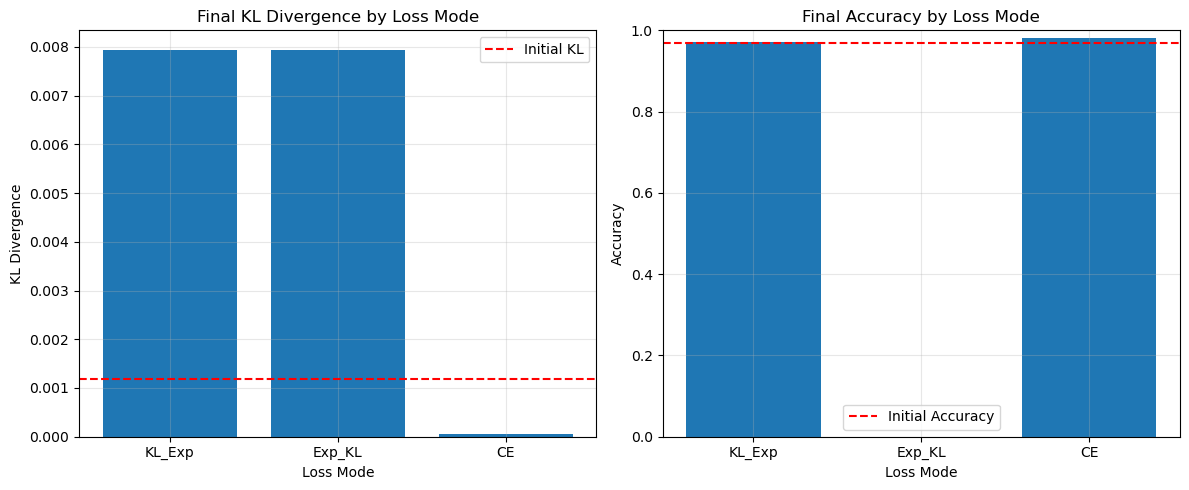

In [20]:
# Create comparison plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# KL Divergence comparison
ax1.bar(results['loss_mode'], results['final_kl'])
ax1.axhline(y=initial_kl, color='red', linestyle='--', label='Initial KL')
ax1.set_xlabel('Loss Mode')
ax1.set_ylabel('KL Divergence')
ax1.set_title('Final KL Divergence by Loss Mode')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy comparison
ax2.bar(results['loss_mode'], results['final_accuracy'])
ax2.axhline(y=initial_accuracy, color='red', linestyle='--', label='Initial Accuracy')
ax2.set_xlabel('Loss Mode')
ax2.set_ylabel('Accuracy')
ax2.set_title('Final Accuracy by Loss Mode')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('loss_functions_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Create results dataframe
df_results = pd.DataFrame(results)
df_results['accuracy_fraction'] = df_results['final_correct'].astype(str) + '/' + df_results['total_samples'].astype(str)

# Add initial values for comparison
initial_row = {
    'loss_mode': 'Initial (No Calibration)',
    'final_kl': initial_kl,
    'final_accuracy': initial_accuracy,
    'final_correct': initial_correct,
    'total_samples': total_samples,
    'training_loss': np.nan,
    'accuracy_fraction': f"{initial_correct}/{total_samples}"
}
df_results = pd.concat([pd.DataFrame([initial_row]), df_results], ignore_index=True)

print("\nResults Summary:")
print(df_results[['loss_mode', 'final_kl', 'final_accuracy', 'accuracy_fraction', 'training_loss']])

# Save results
df_results.to_csv('loss_functions_results.csv', index=False)
print("\nResults saved to loss_functions_results.csv")


Results Summary:
                  loss_mode  final_kl  final_accuracy accuracy_fraction  \
0  Initial (No Calibration)  0.001186        0.969489         1271/1311   
1                    KL_Exp  0.007942        0.970252         1272/1311   
2                    Exp_KL  0.007932        0.000000            0/1311   
3                        CE  0.000051        0.981693         1287/1311   

   training_loss  
0            NaN  
1      -1.814633  
2       3.402111  
3       0.762200  

Results saved to loss_functions_results.csv


## Analysis

In [22]:
# Find best methods
calibrated_results = df_results[df_results['loss_mode'] != 'Initial (No Calibration)']

best_kl_idx = calibrated_results['final_kl'].idxmin()
best_acc_idx = calibrated_results['final_accuracy'].idxmax()

print("Best method for KL divergence:")
print(f"  Loss mode: {df_results.loc[best_kl_idx, 'loss_mode']}")
print(f"  KL divergence: {df_results.loc[best_kl_idx, 'final_kl']:.6f}")
print(f"  Accuracy: {df_results.loc[best_kl_idx, 'final_accuracy']:.4f} ({df_results.loc[best_kl_idx, 'accuracy_fraction']})")

print("\nBest method for accuracy:")
print(f"  Loss mode: {df_results.loc[best_acc_idx, 'loss_mode']}")
print(f"  KL divergence: {df_results.loc[best_acc_idx, 'final_kl']:.6f}")
print(f"  Accuracy: {df_results.loc[best_acc_idx, 'final_accuracy']:.4f} ({df_results.loc[best_acc_idx, 'accuracy_fraction']})")

Best method for KL divergence:
  Loss mode: CE
  KL divergence: 0.000051
  Accuracy: 0.9817 (1287/1311)

Best method for accuracy:
  Loss mode: CE
  KL divergence: 0.000051
  Accuracy: 0.9817 (1287/1311)
